In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("📊 MODEL ANALYSIS NOTEBOOK")
print("="*60)


📊 MODEL ANALYSIS NOTEBOOK


In [2]:

print("\n📦 Loading data and trained models...")

# Load test data
X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy")
print(f"✅ Test data loaded: {X_test.shape}")

# Load trained models
lstm_model = load_model("../models/lstm_model.keras")
gru_model = load_model("../models/gru_model.keras")
print("✅ Models loaded successfully!")



📦 Loading data and trained models...
✅ Test data loaded: (7744, 30, 15)
✅ Models loaded successfully!



📈 CONFIDENCE THRESHOLD ANALYSIS

📊 LSTM Results by Threshold:
   threshold  accuracy  precision  recall      f1  avg_confidence  \
0       0.50    0.6745     0.7044  0.7208  0.7125          0.3425   
1       0.55    0.6648     0.7311  0.6343  0.6793          0.3425   
2       0.60    0.6445     0.7556  0.5392  0.6293          0.3425   
3       0.65    0.6191     0.7804  0.4444  0.5663          0.3425   
4       0.70    0.5873     0.8106  0.3426  0.4817          0.3425   
5       0.75    0.5471     0.8284  0.2407  0.3730          0.3425   
6       0.80    0.5138     0.8729  0.1537  0.2613          0.3425   
7       0.85    0.4855     0.8889  0.0923  0.1672          0.3425   

   high_conf_pct  
0        24.8838  
1        19.3698  
2        14.7986  
3        11.0925  
4         8.3419  
5         5.7206  
6         3.3704  
7         1.5625  

📊 GRU Results by Threshold:
   threshold  accuracy  precision  recall      f1  avg_confidence  \
0       0.50    0.6810     0.7052  0.7390  0.7

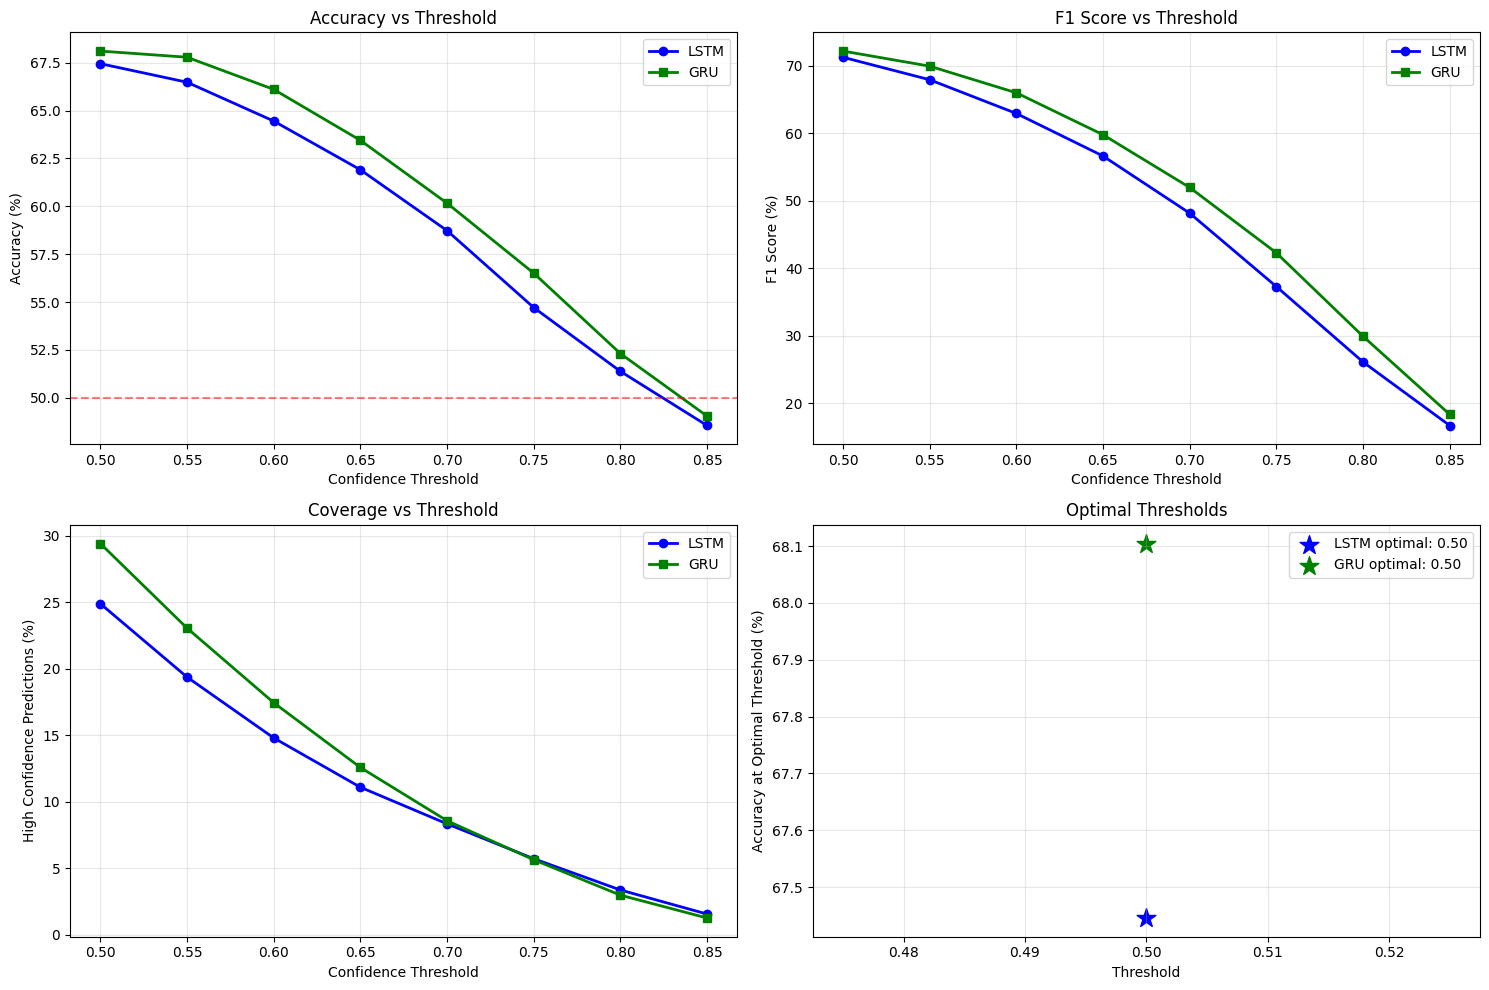

In [3]:
print("\n" + "="*60)
print("📈 CONFIDENCE THRESHOLD ANALYSIS")
print("="*60)

def analyze_thresholds(model, X_test, y_test, model_name):
    """Analyze model performance at different confidence thresholds"""
    
    # Get predictions
    y_pred_prob = model.predict(X_test, verbose=0).flatten()
    
    thresholds = np.arange(0.5, 0.9, 0.05)
    results = []
    
    for thresh in thresholds:
        y_pred = (y_pred_prob > thresh).astype(int)
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        
        # Calculate confidence scores
        confidence = np.abs(y_pred_prob - 0.5) * 2
        avg_confidence = confidence.mean()
        high_conf_pct = (confidence > thresh).mean() * 100
        
        results.append({
            'threshold': thresh,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'avg_confidence': avg_confidence,
            'high_conf_pct': high_conf_pct
        })
    
    return pd.DataFrame(results)

# Analyze both models
lstm_results = analyze_thresholds(lstm_model, X_test, y_test, "LSTM")
gru_results = analyze_thresholds(gru_model, X_test, y_test, "GRU")

print("\n📊 LSTM Results by Threshold:")
print(lstm_results.round(4))

print("\n📊 GRU Results by Threshold:")
print(gru_results.round(4))

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy vs Threshold
ax1 = axes[0, 0]
ax1.plot(lstm_results['threshold'], lstm_results['accuracy']*100, 
         marker='o', linewidth=2, label='LSTM', color='blue')
ax1.plot(gru_results['threshold'], gru_results['accuracy']*100, 
         marker='s', linewidth=2, label='GRU', color='green')
ax1.axhline(y=50, color='red', linestyle='--', alpha=0.5)
ax1.set_xlabel('Confidence Threshold')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy vs Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# F1 vs Threshold
ax2 = axes[0, 1]
ax2.plot(lstm_results['threshold'], lstm_results['f1']*100, 
         marker='o', linewidth=2, label='LSTM', color='blue')
ax2.plot(gru_results['threshold'], gru_results['f1']*100, 
         marker='s', linewidth=2, label='GRU', color='green')
ax2.set_xlabel('Confidence Threshold')
ax2.set_ylabel('F1 Score (%)')
ax2.set_title('F1 Score vs Threshold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# High Confidence Percentage
ax3 = axes[1, 0]
ax3.plot(lstm_results['threshold'], lstm_results['high_conf_pct'], 
         marker='o', linewidth=2, label='LSTM', color='blue')
ax3.plot(gru_results['threshold'], gru_results['high_conf_pct'], 
         marker='s', linewidth=2, label='GRU', color='green')
ax3.set_xlabel('Confidence Threshold')
ax3.set_ylabel('High Confidence Predictions (%)')
ax3.set_title('Coverage vs Threshold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Find optimal threshold
ax4 = axes[1, 1]
for model, results, color in [('LSTM', lstm_results, 'blue'), ('GRU', gru_results, 'green')]:
    # Calculate combined score (accuracy * coverage)
    combined = results['accuracy'] * results['high_conf_pct'] / 100
    optimal_idx = combined.idxmax()
    optimal_thresh = results.loc[optimal_idx, 'threshold']
    optimal_acc = results.loc[optimal_idx, 'accuracy'] * 100
    optimal_coverage = results.loc[optimal_idx, 'high_conf_pct']
    
    ax4.scatter(optimal_thresh, optimal_acc, s=200, color=color, marker='*', 
                label=f'{model} optimal: {optimal_thresh:.2f}')
    
ax4.set_xlabel('Threshold')
ax4.set_ylabel('Accuracy at Optimal Threshold (%)')
ax4.set_title('Optimal Thresholds')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



🎯 DEEP LEARNING ENSEMBLE (LSTM + GRU)

📊 Ensemble Methods Comparison:
  AVERAGE: Accuracy=68.39%, F1=72.29%
  PRODUCT: Accuracy=68.39%, F1=72.29%
  MAX: Accuracy=68.12%, F1=73.29%

📊 Confidence-Based Filtering:
   threshold  accuracy  coverage      f1
0       0.50    0.8285   21.5393  0.8704
1       0.55    0.8409   15.9866  0.8817
2       0.60    0.8540   11.7639  0.8958
3       0.65    0.8758    8.0062  0.9149
4       0.70    0.9007    5.4623  0.9350


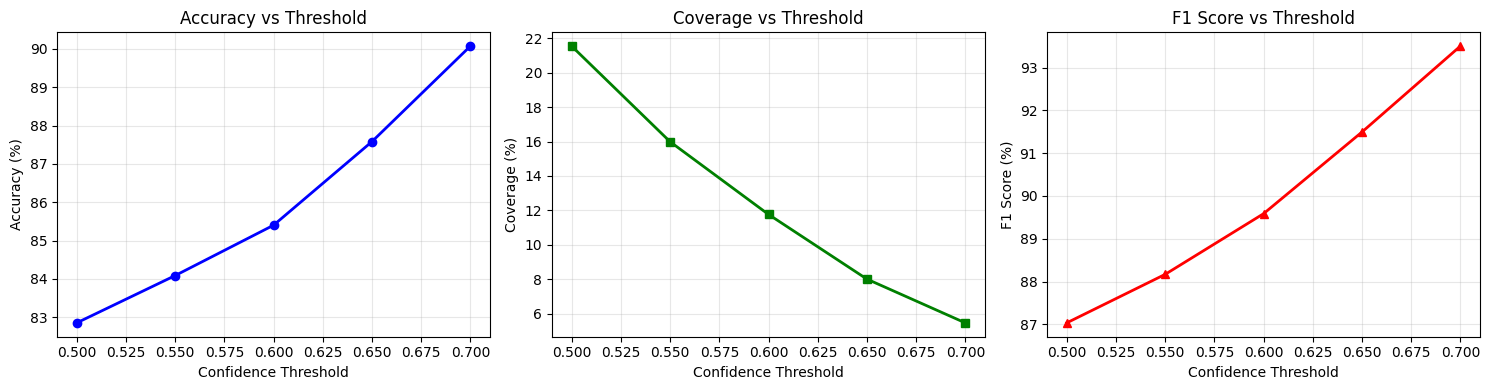

In [4]:
# ============================================
# STEP 3: DEEP LEARNING ENSEMBLE
# ============================================

print("\n" + "="*60)
print("🎯 DEEP LEARNING ENSEMBLE (LSTM + GRU)")
print("="*60)

class DeepEnsemble:
    def __init__(self, lstm_model, gru_model):
        self.lstm = lstm_model
        self.gru = gru_model
    
    def predict(self, X, method='average', threshold=0.5):
        lstm_probs = self.lstm.predict(X, verbose=0).flatten()
        gru_probs = self.gru.predict(X, verbose=0).flatten()
        
        if method == 'average':
            ensemble_probs = (lstm_probs + gru_probs) / 2
        elif method == 'product':
            ensemble_probs = lstm_probs * gru_probs
            ensemble_probs = ensemble_probs / (ensemble_probs + (1-lstm_probs)*(1-gru_probs))
        elif method == 'max':
            ensemble_probs = np.maximum(lstm_probs, gru_probs)
        else:
            ensemble_probs = (lstm_probs + gru_probs) / 2
        
        ensemble_pred = (ensemble_probs > threshold).astype(int)
        return ensemble_pred, ensemble_probs
    
    def predict_with_confidence(self, X, confidence_threshold=0.6):
        lstm_probs = self.lstm.predict(X, verbose=0).flatten()
        gru_probs = self.gru.predict(X, verbose=0).flatten()
        
        # Agreement and confidence
        agreement = 1 - np.abs(lstm_probs - gru_probs)
        avg_probs = (lstm_probs + gru_probs) / 2
        confidence = agreement * (np.abs(avg_probs - 0.5) * 2)
        
        predictions = np.zeros_like(avg_probs)
        predictions[avg_probs > 0.5] = 1
        predictions[confidence < confidence_threshold] = -1
        
        return predictions, avg_probs, confidence
    
    def evaluate_with_confidence(self, X_test, y_test, thresholds=[0.5, 0.55, 0.6, 0.65, 0.7]):
        results = []
        for thresh in thresholds:
            pred, probs, conf = self.predict_with_confidence(X_test, confidence_threshold=thresh)
            certain_mask = pred != -1
            if certain_mask.sum() > 0:
                acc = accuracy_score(y_test[certain_mask], pred[certain_mask])
                coverage = certain_mask.mean() * 100
                f1 = f1_score(y_test[certain_mask], pred[certain_mask], zero_division=0)
                results.append({
                    'threshold': thresh,
                    'accuracy': acc,
                    'coverage': coverage,
                    'f1': f1
                })
        return pd.DataFrame(results)

# Create ensemble
ensemble = DeepEnsemble(lstm_model, gru_model)

# Test different ensemble methods
print("\n📊 Ensemble Methods Comparison:")
methods = ['average', 'product', 'max']
for method in methods:
    pred, probs = ensemble.predict(X_test, method=method)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, zero_division=0)
    print(f"  {method.upper()}: Accuracy={acc*100:.2f}%, F1={f1*100:.2f}%")

# Confidence-based filtering
print("\n📊 Confidence-Based Filtering:")
conf_results = ensemble.evaluate_with_confidence(X_test, y_test)
print(conf_results.round(4))

# Plot confidence results
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(conf_results['threshold'], conf_results['accuracy']*100, 
         marker='o', linewidth=2, color='blue')
plt.xlabel('Confidence Threshold')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Threshold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(conf_results['threshold'], conf_results['coverage'], 
         marker='s', linewidth=2, color='green')
plt.xlabel('Confidence Threshold')
plt.ylabel('Coverage (%)')
plt.title('Coverage vs Threshold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(conf_results['threshold'], conf_results['f1']*100, 
         marker='^', linewidth=2, color='red')
plt.xlabel('Confidence Threshold')
plt.ylabel('F1 Score (%)')
plt.title('F1 Score vs Threshold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:

print("\n" + "="*60)
print("🎯 FINAL RECOMMENDATIONS")
print("="*60)

# Find best threshold for ensemble
best_idx = (conf_results['accuracy'] * conf_results['coverage']/100).idxmax()
best = conf_results.loc[best_idx]

print(f"""
Based on analysis:

1. BEST CONFIDENCE THRESHOLD: {best['threshold']}
   - Accuracy: {best['accuracy']*100:.2f}%
   - Coverage: {best['coverage']:.1f}% of predictions
   - F1 Score: {best['f1']*100:.2f}%

2. ENSEMBLE METHOD: Average (simplest and most stable)

3. STRATEGY:
   - Use ensemble with threshold {best['threshold']}
   - Only act on predictions with confidence ≥ {best['threshold']}
   - For {best['coverage']:.1f}% of cases, you get {best['accuracy']*100:.2f}% accuracy
   - For remaining cases, use traditional analysis or hold

4. EXPECTED IMPROVEMENT:
   - Before: 47.6% accuracy on all predictions
   - After: {best['accuracy']*100:.2f}% accuracy on {best['coverage']:.1f}% of predictions
""")

# ============================================
# STEP 5: SAVE RESULTS
# ============================================

print("\n" + "="*60)
print("💾 SAVING ANALYSIS RESULTS")
print("="*60)

# Save results
lstm_results.to_csv('../models/lstm_threshold_analysis.csv', index=False)
gru_results.to_csv('../models/gru_threshold_analysis.csv', index=False)
conf_results.to_csv('../models/ensemble_analysis.csv', index=False)

print("✅ Analysis saved to models folder")
print("   - lstm_threshold_analysis.csv")
print("   - gru_threshold_analysis.csv")
print("   - ensemble_analysis.csv")


🎯 FINAL RECOMMENDATIONS

Based on analysis:

1. BEST CONFIDENCE THRESHOLD: 0.5
   - Accuracy: 82.85%
   - Coverage: 21.5% of predictions
   - F1 Score: 87.04%

2. ENSEMBLE METHOD: Average (simplest and most stable)

3. STRATEGY:
   - Use ensemble with threshold 0.5
   - Only act on predictions with confidence ≥ 0.5
   - For 21.5% of cases, you get 82.85% accuracy
   - For remaining cases, use traditional analysis or hold

4. EXPECTED IMPROVEMENT:
   - Before: 47.6% accuracy on all predictions
   - After: 82.85% accuracy on 21.5% of predictions


💾 SAVING ANALYSIS RESULTS
✅ Analysis saved to models folder
   - lstm_threshold_analysis.csv
   - gru_threshold_analysis.csv
   - ensemble_analysis.csv
